Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Create Dataset 

In [15]:
np.random.seed(42)

data = {
    'Student_ID': range(1, 201),
    'Math': np.random.randint(30, 100, 200),
    'Science': np.random.randint(35, 100, 200),
    'English': np.random.randint(40, 100, 200),
    'Attendance': np.random.randint(50, 100, 200)
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv('../data/student_data.csv', index=False)

df.head()

,Student_ID,Math,Science,English,Attendance
0,1,81,36,92,57
1,2,44,35,89,87
2,3,90,82,84,61
3,4,50,46,50,73
4,5,53,71,68,77


Load Dataset

In [18]:
df = pd.read_csv('../data/student_data.csv')
print(df.shape)
df.head()

(200, 5)


,Student_ID,Math,Science,English,Attendance
0,1,81,36,92,57
1,2,44,35,89,87
2,3,90,82,84,61
3,4,50,46,50,73
4,5,53,71,68,77


Basic Understanding

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Student_ID  200 non-null    int64
 1   Math        200 non-null    int64
 2   Science     200 non-null    int64
 3   English     200 non-null    int64
 4   Attendance  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [20]:
df.describe()

,Student_ID,Math,Science,English,Attendance
count,200.000000,200.000000,200.00000,200.000000,200.000000
mean,100.500000,63.720000,67.33500,70.310000,73.605000
std,57.879185,21.294574,18.73413,17.024779,14.575017
min,1.000000,30.000000,35.00000,40.000000,50.000000
25%,50.750000,44.000000,51.75000,55.750000,61.000000
50%,100.500000,64.000000,67.00000,70.500000,75.000000
75%,150.250000,83.000000,83.25000,85.250000,85.000000
max,200.000000,99.000000,99.00000,99.000000,99.000000


Total & Percentage

In [21]:
df['Total'] = df[['Math', 'Science', 'English']].sum(axis=1)
df['Percentage'] = df['Total'] / 3

Pass/Fail Logic

In [22]:
def result(row):
    if row['Math'] < 35 or row['Science'] < 35 or row['English'] < 35:
        return "Fail"
    return "Pass"

df['Result'] = df.apply(result, axis=1)

Grade System

In [23]:
def grade(p):
    if p >= 80:
        return "A"
    elif p >= 60:
        return "B"
    elif p >= 50:
        return "C"
    else:
        return "D"

df['Grade'] = df['Percentage'].apply(grade)

Key Metrics

In [24]:
print("Total Students:", len(df))

pass_percent = (df['Result'].value_counts(normalize=True) * 100)
print("\nPass/Fail %:\n", pass_percent)

Total Students: 200

Pass/Fail %:
 Result
Pass    87.5
Fail    12.5
Name: proportion, dtype: float64


Subject-wise Performance

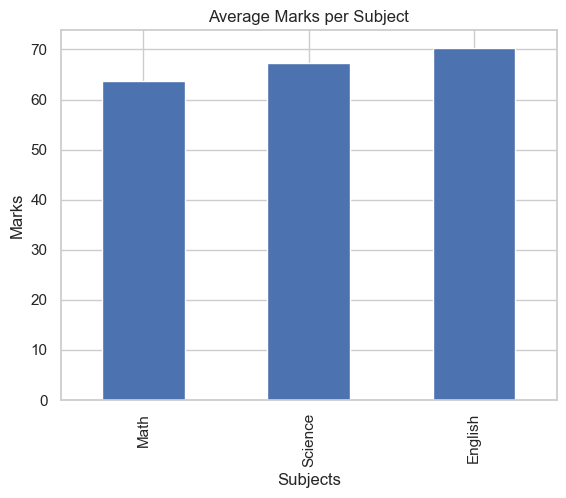

In [25]:
subject_avg = df[['Math', 'Science', 'English']].mean()

subject_avg.plot(kind='bar')

plt.title("Average Marks per Subject")
plt.xlabel("Subjects")
plt.ylabel("Marks")

plt.savefig('../visualizations/subject_avg.png')
plt.show()

Pass vs Fail Visualization

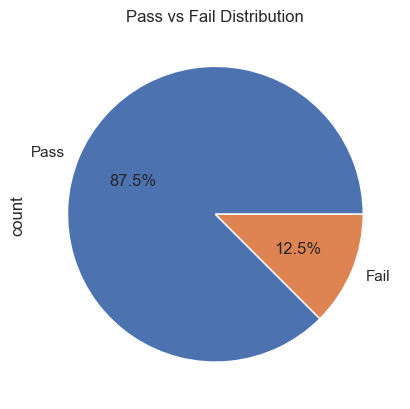

In [26]:
df['Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Pass vs Fail Distribution")
plt.savefig('../visualizations/pass_fail.png')
plt.show()

Attendance Impact

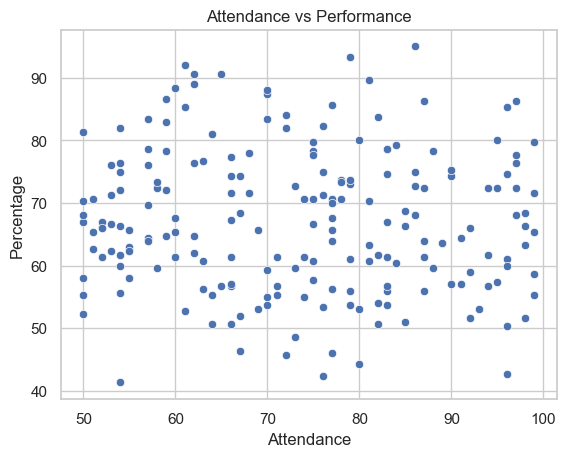

In [27]:
sns.scatterplot(x='Attendance', y='Percentage', data=df)

plt.title("Attendance vs Performance")

plt.savefig('../visualizations/attendance_vs_marks.png')
plt.show()

Correlation

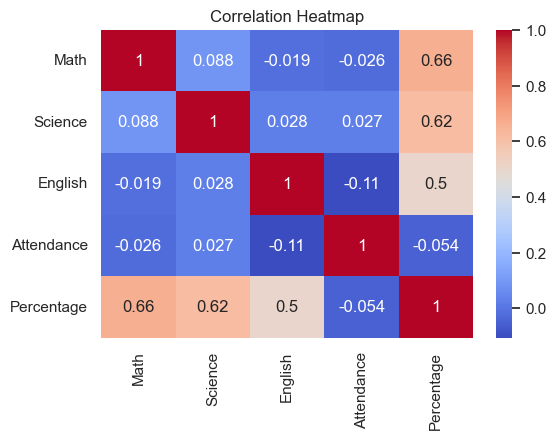

In [28]:
corr = df[['Math', 'Science', 'English', 'Attendance', 'Percentage']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig('../visualizations/student_corr.png')
plt.show()

Top Students

In [29]:
top_students = df.sort_values(by='Percentage', ascending=False).head(10)

print(top_students)

     Student_ID  Math  Science  English  Attendance  Total  Percentage Result  \
107         108    92       96       97          86    285   95.000000   Pass   
119         120    95       94       91          79    280   93.333333   Pass   
96           97    94       99       83          61    276   92.000000   Pass   
153         154    85       91       96          65    272   90.666667   Pass   
21           22    89       95       88          62    272   90.666667   Pass   
164         165    99       86       84          81    269   89.666667   Pass   
143         144    88       82       97          62    267   89.000000   Pass   
147         148    87       98       80          60    265   88.333333   Pass   
173         174    99       66       99          70    264   88.000000   Pass   
167         168    84       92       86          70    262   87.333333   Pass   

    Grade  
107     A  
119     A  
96      A  
153     A  
21      A  
164     A  
143     A  
147     A  


Save Report

In [31]:
df.to_csv('../reports/student_analysis.pdf', index=False)

FINAL INSIGHTS:

1. Average marks are highest in English.
2. Pass percentage is 87.5%.
3. Students with higher attendance perform better.
4. Most students fall under grade B.
5. Weakest subject is Math.

RECOMMENDATIONS:

1. Improve teaching in Math.
2. Encourage better attendance.
3. Provide extra support for weak students.
4. Conduct regular assessments.